# <font face = 'Impact' color = '#E7625F' > Sample Demonstration on Machine Learning for Regression: Home Price Prediction<font/>
#### <font face = 'Times New Roman' color = '#1F6CB0'> License: GPL v3.0<font/>
#### <font face = 'Times New Roman' color = '#1F6CB0'> Author and Trainer: Paolo Hilado MSc. (Data Science)<font/>
This notebook provides a backgrounder in doing Machine Learning in Python employing models such as Ridge Regression, LASSO Regression, and Elastic Net

# Business Understanding

## 1.1 Business Context
A hypothetical real-estate company, HomeValue Analytics, wants to improve the way it estimates residential property prices. Currently, property prices are estimated using a combination of historical sales, agent experience, location, property size, and other characteristics.  

The company wants to use machine learning to develop a data-driven system that can estimate the expected selling price of a residential property based on its characteristics.  

The proposed machine-learning solution will use historical property information such as:  

Property size  
Number of bedrooms  
Number of bathrooms  
Property age  
Distance from the city center  
Distance from schools  
Distance from shopping centers  
Neighborhood quality  
Parking availability  
Property condition  
The target variable will be the property selling price, making this a supervised regression problem.

## 1.2 Business Problem  
HomeValue Analytics currently relies heavily on manual valuation and simple historical comparisons. This can lead to inconsistent property valuations, particularly when there are many properties with different characteristics.

An inaccurate valuation can result in:
- Properties being overpriced and remaining on the market for too long.
- Properties being underpriced and reducing potential revenue.
- Inconsistent recommendations from different agents.
- Difficulty determining competitive listing prices.
- Increased time required to evaluate properties.
- The business therefore needs a systematic method for estimating property prices.

## 1.3 Business Objective  
The primary business objective is to develop a machine-learning model that can accurately estimate the selling price of residential properties based on their characteristics. The model could eventually be used by property agents as a decision-support tool when preparing property valuations and listing recommendations.


## 1.4 Data Mining Objective
The data-mining objective is to develop a regression model that predicts the continuous variable:  

### selling_price 

using property-related predictor variables.  

The analysis will involve:  

- Loading and exploring the dataset.
- Performing Exploratory Data Analysis
- Data Partitioning
- Data Preprocessing (Feature Scaling and One-hot Coding) and Data Cleaning (when needed)
- Machine Learning Development and Performance Evaluation using RMSE


## 1.5 Business Assumptions  
The hypothetical project makes the following assumptions:  

- Historical property characteristics are reasonably representative of properties that will be evaluated in the future.
- Property size generally has a positive relationship with selling price.
- Properties with more bedrooms and bathrooms generally have higher prices.
- Better neighborhood quality is associated with higher property prices.
- Properties closer to major amenities tend to have higher values.
- Newer properties tend to have higher values than otherwise comparable older properties.
- Property condition influences its selling price.
- The relationship between property characteristics and price is sufficiently strong for regression modeling.
- There are no major changes in the hypothetical property market that would completely invalidate historical relationships.

## 1.6 Success Criteria
Business Success Criteria  
The project will be considered successful if the resulting model:  

Provides reasonably accurate property-price estimates.  
Performs better than a simple baseline prediction, such as predicting the average property price.  
Can support property agents in making consistent valuation decisions.  
Produces predictions that are sufficiently reliable for preliminary property assessment.  

R² ≥ 0.80 on the test dataset.  
RMSE should be reasonably small relative to the typical property price.  
MAE should be sufficiently low that the average prediction error is acceptable to the business.  
The model should not exhibit a large difference between training and testing performance, indicating severe overfitting.  
These thresholds are illustrative and would need to be validated with actual business stakeholders using real property-market data.  

# 2. Data Understanding

## 2.1 Data Owner
The hypothetical data owner is:  

HomeValue Analytics – Property Valuation Department  

The department is assumed to maintain historical information about residential properties and their associated selling prices.  

Because this is a hypothetical project, the organization and dataset do not represent an actual company or proprietary database.  

## 2.2 Data Source
The dataset is hypothetical; it is not collected from real customers, property owners, or real estate transactions.

The variables and their approximate relationships are designed to resemble a residential property-price dataset. The selling price will be generated using a combination of property characteristics and random variation.  

## 2.3 Data Licensing
The dataset is hypothetical and synthetically generated for educational and demonstration purposes.  
License: Creative Commons Attribution 4.0 International (CC BY 4.0), for the purposes of this demonstration.  
No real person's personal information or proprietary business information is included.  
If this project were later converted to use real property data, the licensing terms would need to be reviewed before the data could be distributed or used for modeling.  

## 2.4 Data Format
The dataset is in a CSV format.  
The dataset contains both numerical and categorical variables.  

## 2.5 Dataset Dimensions
For this project, we will generate:  

1,000 observations (rows)  
15 columns  

## 2.6 Data Dictionary

| Variable | Data Type | Description | Role |
|---|---|---|---|
| `property_id` | String | Unique identifier assigned to each property | Identifier |
| `property_size_sqft` | Float | Size of the property in square feet | Predictor |
| `bedrooms` | Integer | Number of bedrooms in the property | Predictor |
| `bathrooms` | Float | Number of bathrooms in the property | Predictor |
| `property_age` | Integer | Age of the property in years | Predictor |
| `distance_city_km` | Float | Distance from the city center in kilometers | Predictor |
| `distance_school_km` | Float | Distance from the nearest school in kilometers | Predictor |
| `distance_shopping_km` | Float | Distance from the nearest shopping center in kilometers | Predictor |
| `neighborhood_quality` | Integer | Neighborhood quality score from 1 to 10 | Predictor |
| `parking_spaces` | Integer | Number of available parking spaces | Predictor |
| `property_condition` | Categorical | Overall condition of the property | Predictor |
| `property_type` | Categorical | Type of residential property | Predictor |
| `has_pool` | Integer | Whether the property has a swimming pool (0 = No, 1 = Yes) | Predictor |
| `has_garden` | Integer | Whether the property has a garden (0 = No, 1 = Yes) | Predictor |
| `selling_price` | Float | Hypothetical selling price of the property | Target |


In [10]:
# Load the data set
import pandas as pd

df = pd.read_csv("property_price_dataset.csv")
df.head(3)

,property_id,property_size_sqft,bedrooms,bathrooms,property_age,distance_city_km,distance_school_km,distance_shopping_km,neighborhood_quality,parking_spaces,property_condition,property_type,has_pool,has_garden,selling_price
0,PROP_0001,2098.03,2,2.0,17,3.17,7.54,6.09,6,2,Very Good,Apartment,0,1,710276.02
1,PROP_0002,1717.04,2,1.0,1,2.33,0.57,4.41,1,2,Very Good,Townhouse,1,1,661452.17
2,PROP_0003,2188.61,4,1.5,12,14.28,2.95,4.63,4,0,Very Good,Townhouse,1,0,630912.90



--- Variable: property_size_sqft ---
  Anderson-Darling Statistic : 0.5975
  p-value : 0.1240
  Decision : Fail to Reject Null


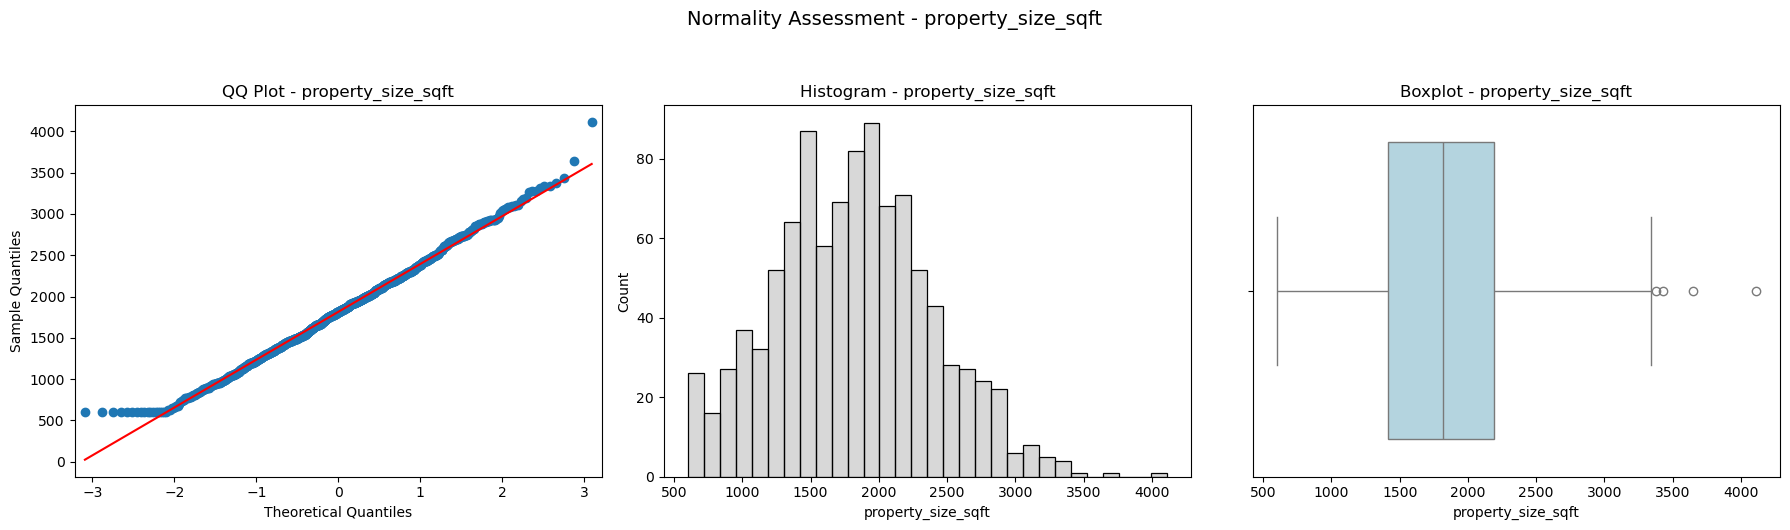


--- Variable: bedrooms ---
  Anderson-Darling Statistic : 31.2662
  p-value : 0.0100
  Decision : Reject Null


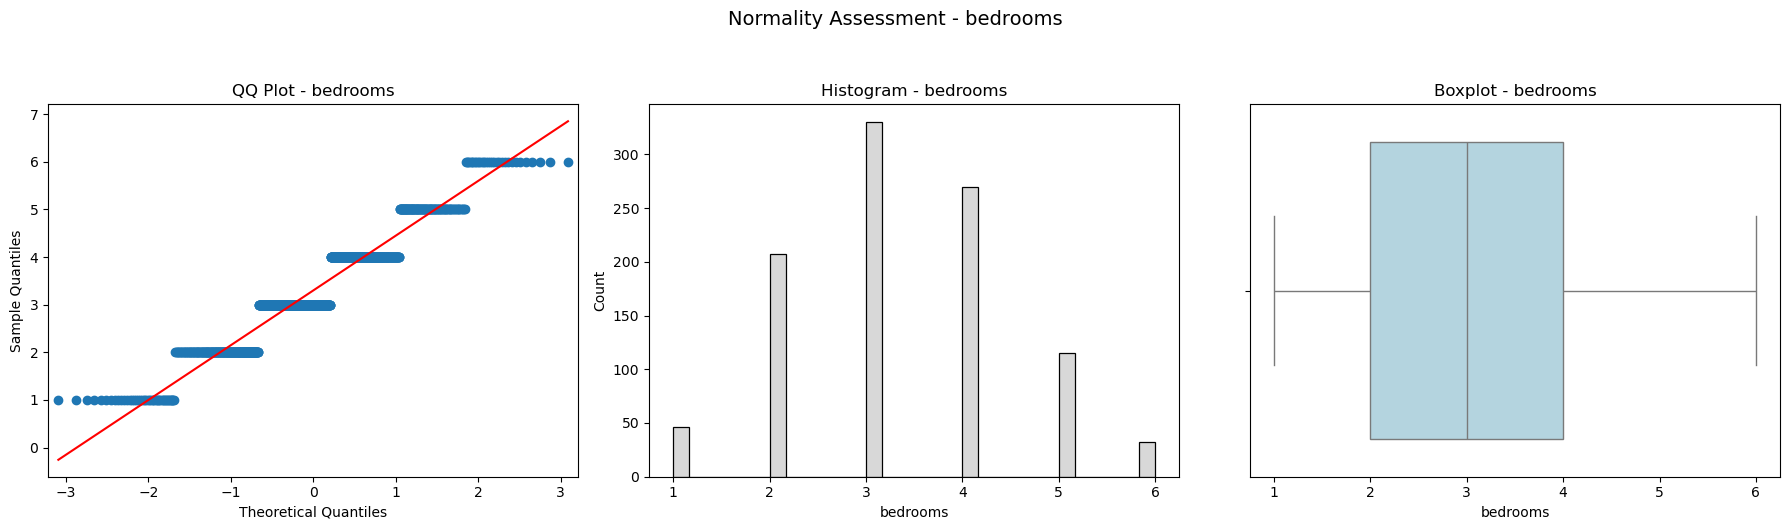


--- Variable: bathrooms ---
  Anderson-Darling Statistic : 26.8759
  p-value : 0.0100
  Decision : Reject Null


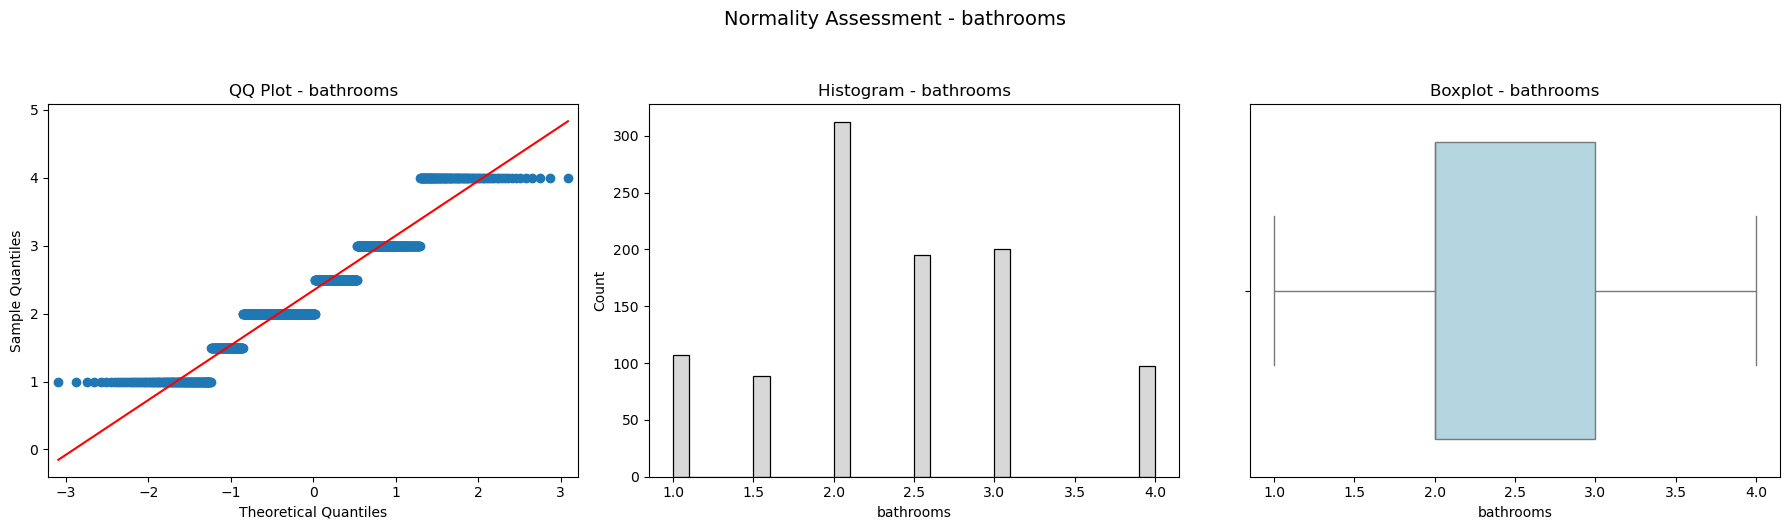


--- Variable: property_age ---
  Anderson-Darling Statistic : 9.6963
  p-value : 0.0100
  Decision : Reject Null


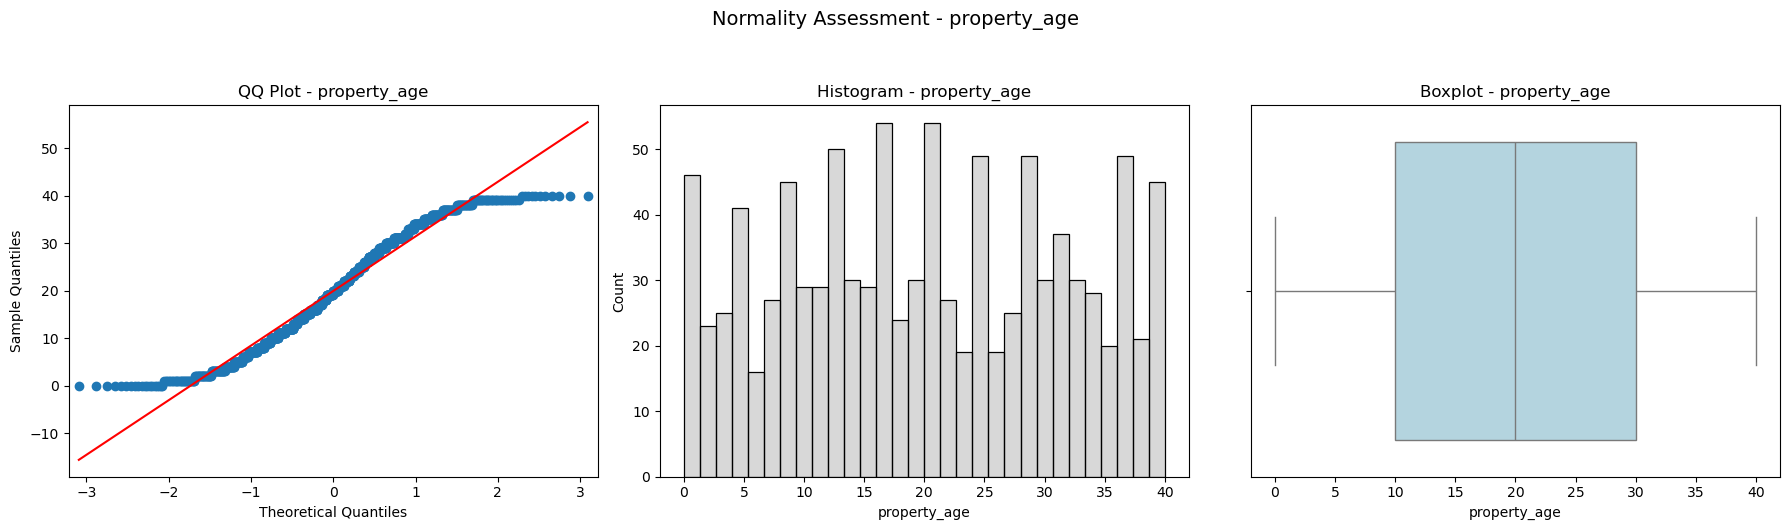


--- Variable: distance_city_km ---
  Anderson-Darling Statistic : 26.8360
  p-value : 0.0100
  Decision : Reject Null


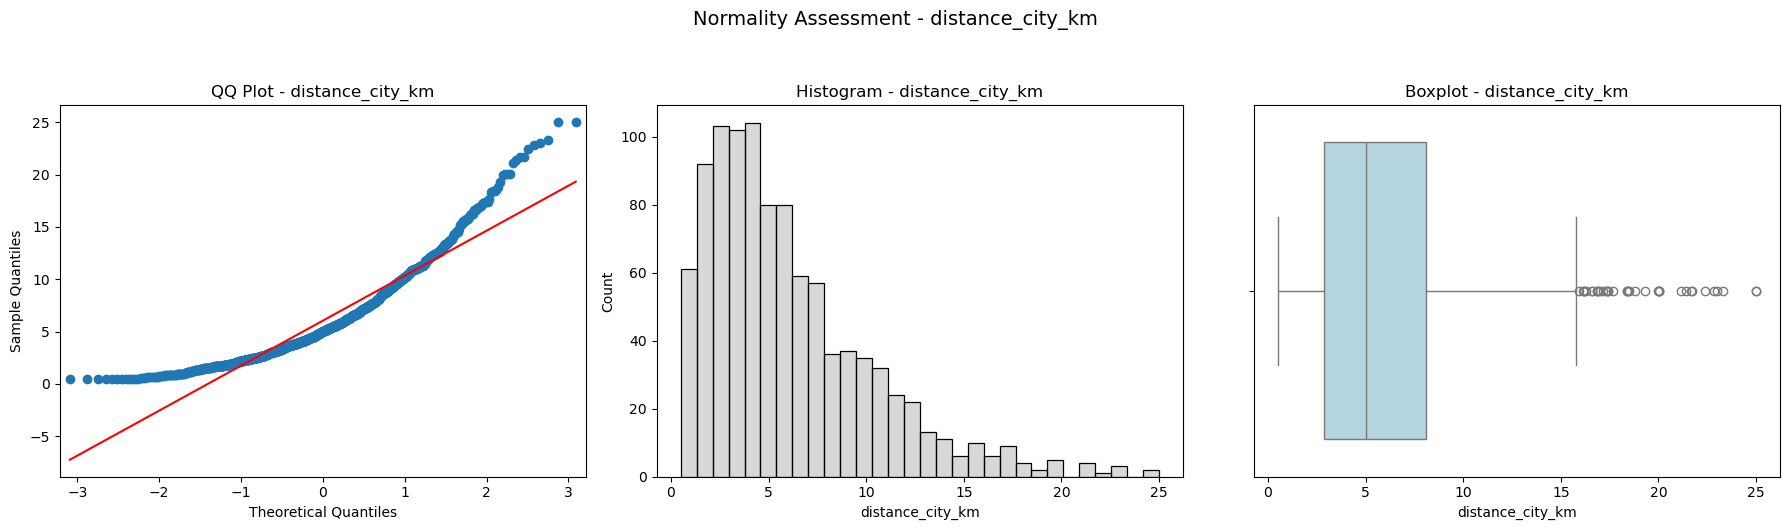


--- Variable: distance_school_km ---
  Anderson-Darling Statistic : 11.9603
  p-value : 0.0100
  Decision : Reject Null


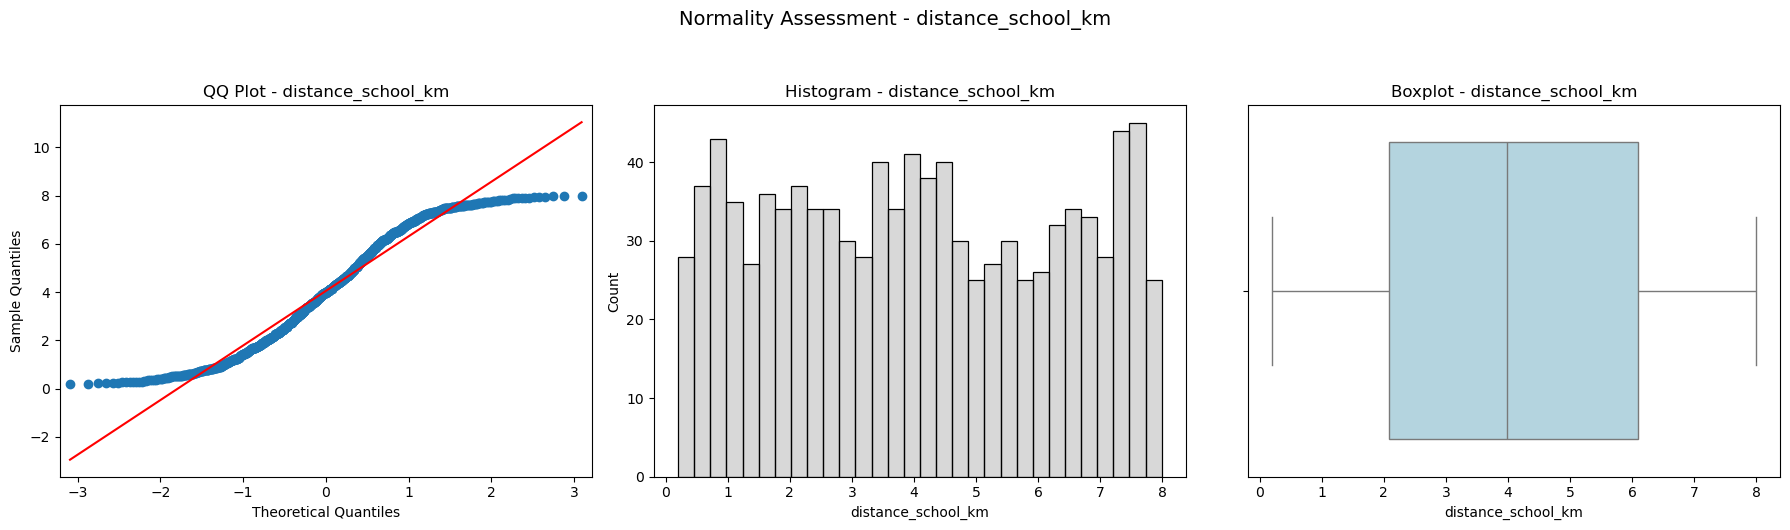


--- Variable: distance_shopping_km ---
  Anderson-Darling Statistic : 9.5584
  p-value : 0.0100
  Decision : Reject Null


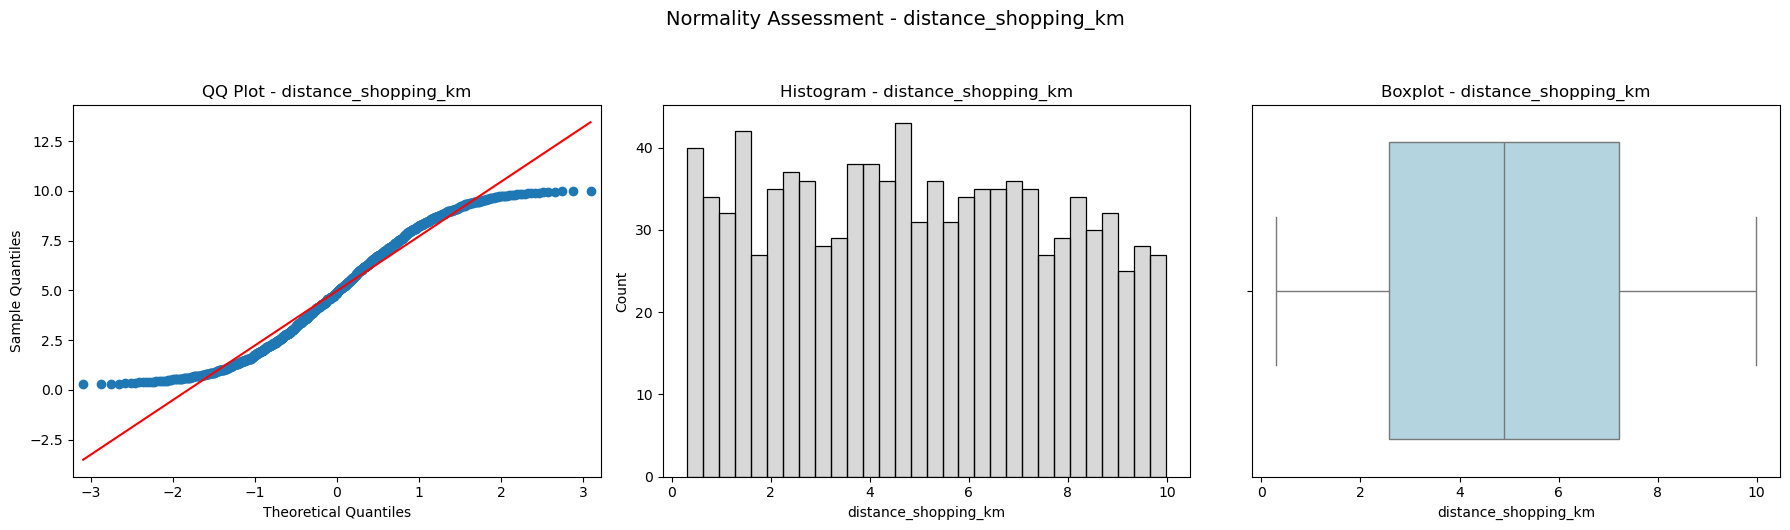


--- Variable: neighborhood_quality ---
  Anderson-Darling Statistic : 15.7714
  p-value : 0.0100
  Decision : Reject Null


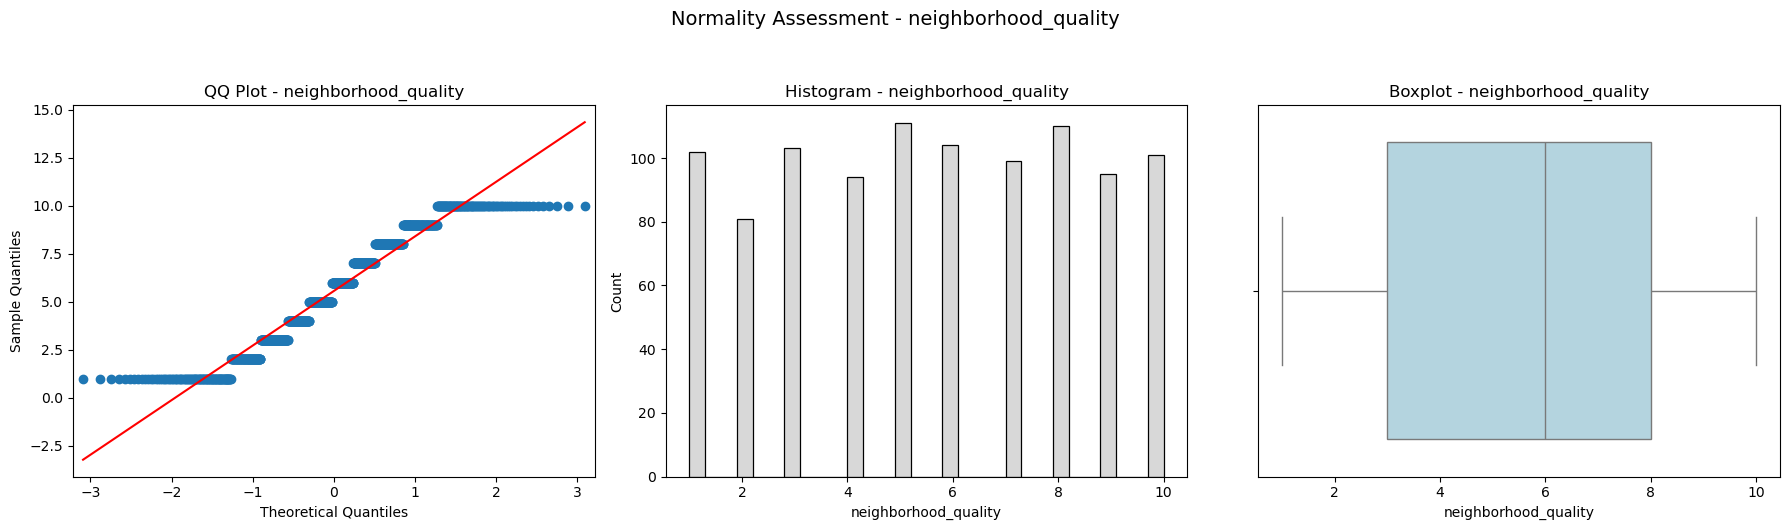


--- Variable: parking_spaces ---
  Anderson-Darling Statistic : 52.1177
  p-value : 0.0100
  Decision : Reject Null


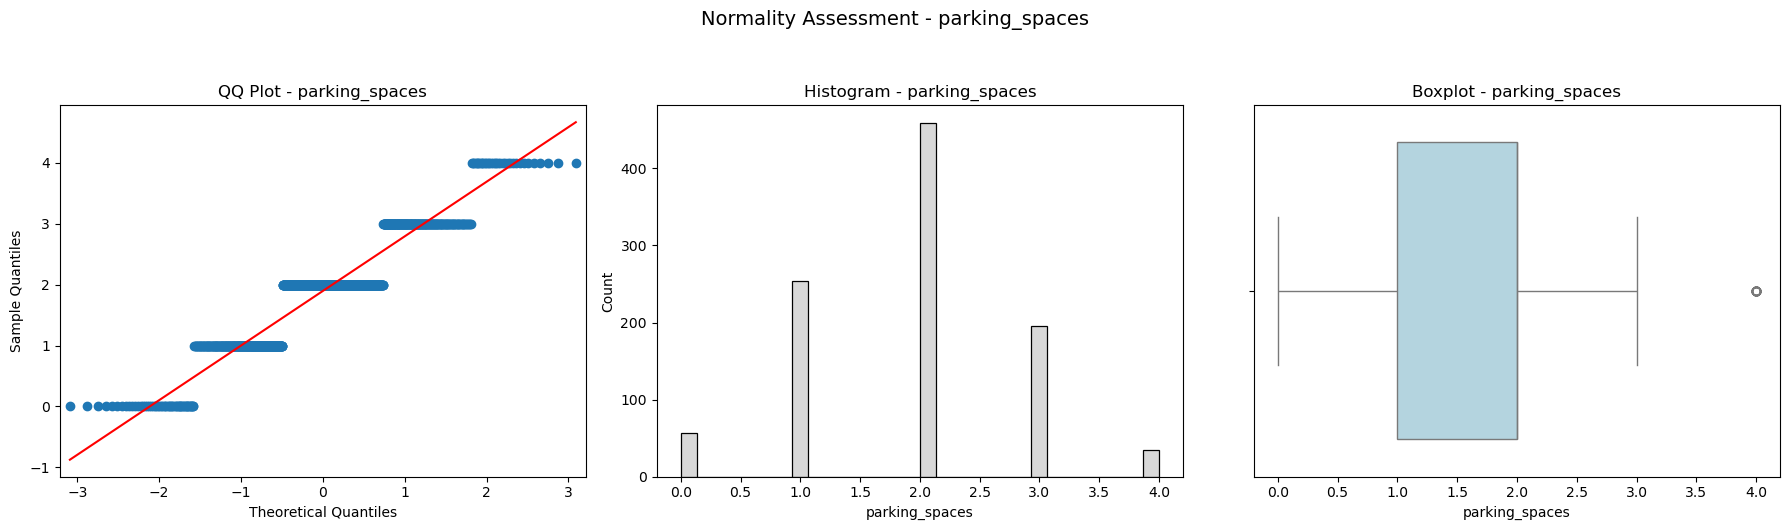


--- Variable: has_pool ---
  Anderson-Darling Statistic : 238.4190
  p-value : 0.0100
  Decision : Reject Null


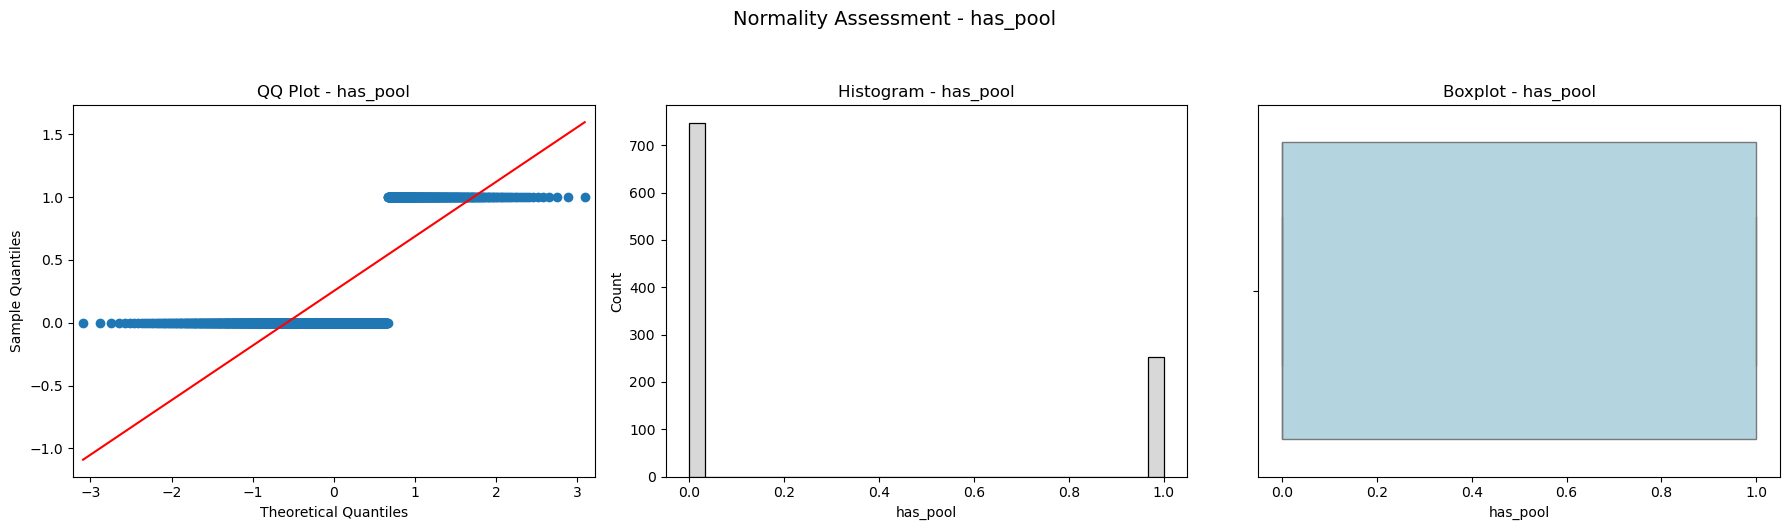


--- Variable: has_garden ---
  Anderson-Darling Statistic : 180.8637
  p-value : 0.0100
  Decision : Reject Null


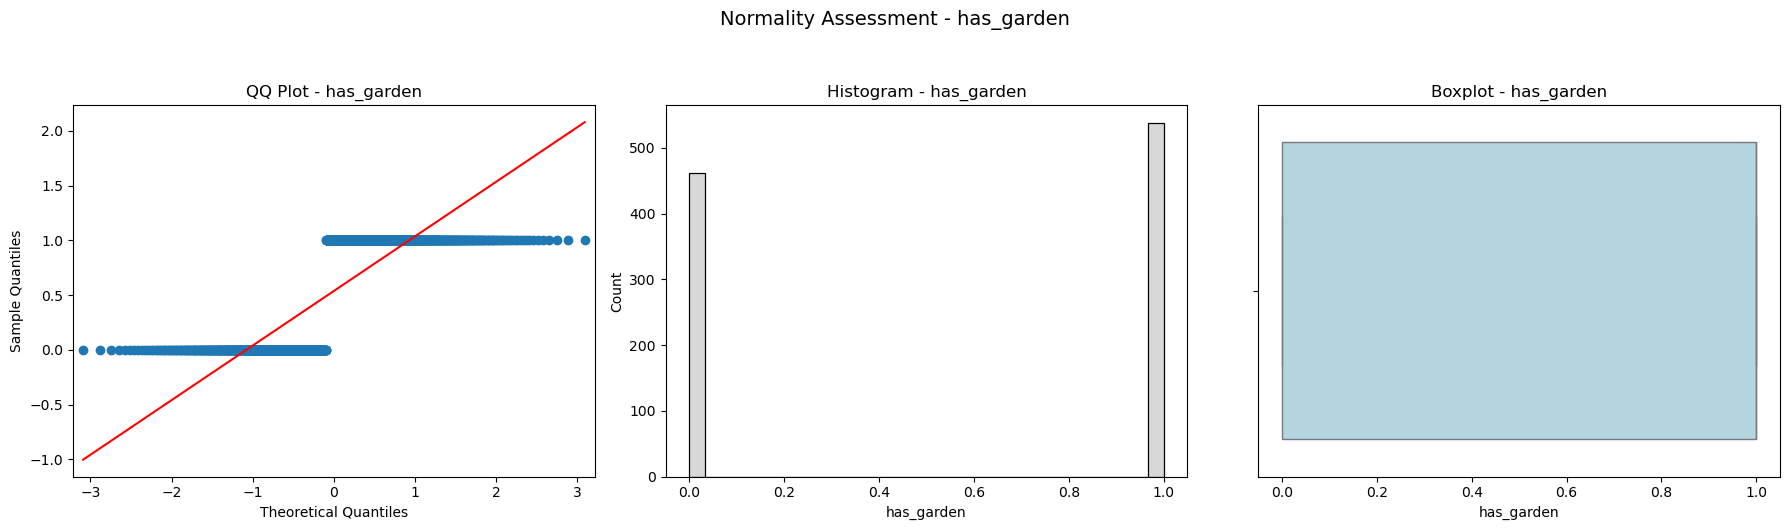


--- Variable: selling_price ---
  Anderson-Darling Statistic : 0.3318
  p-value : 0.1500
  Decision : Fail to Reject Null


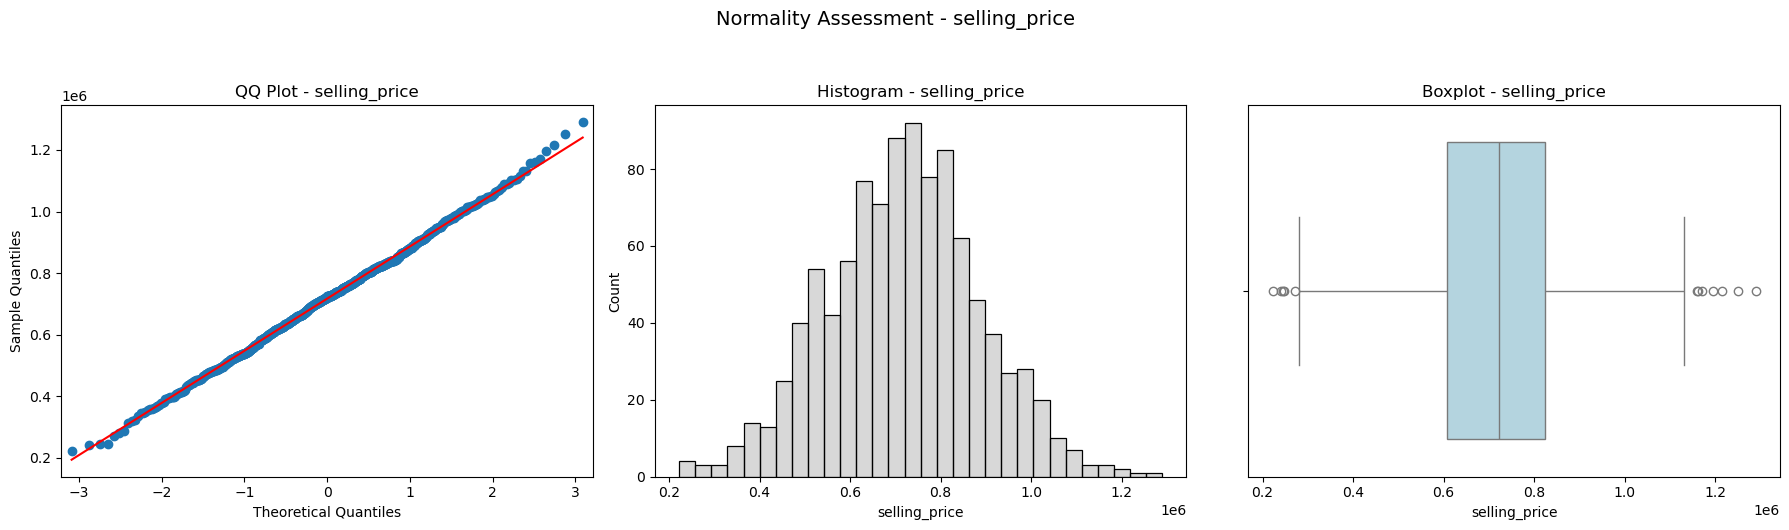

In [2]:
# Perform Exploratory Data Analysis
import qdesc as qd
qd.normcheck_dashboard(df)

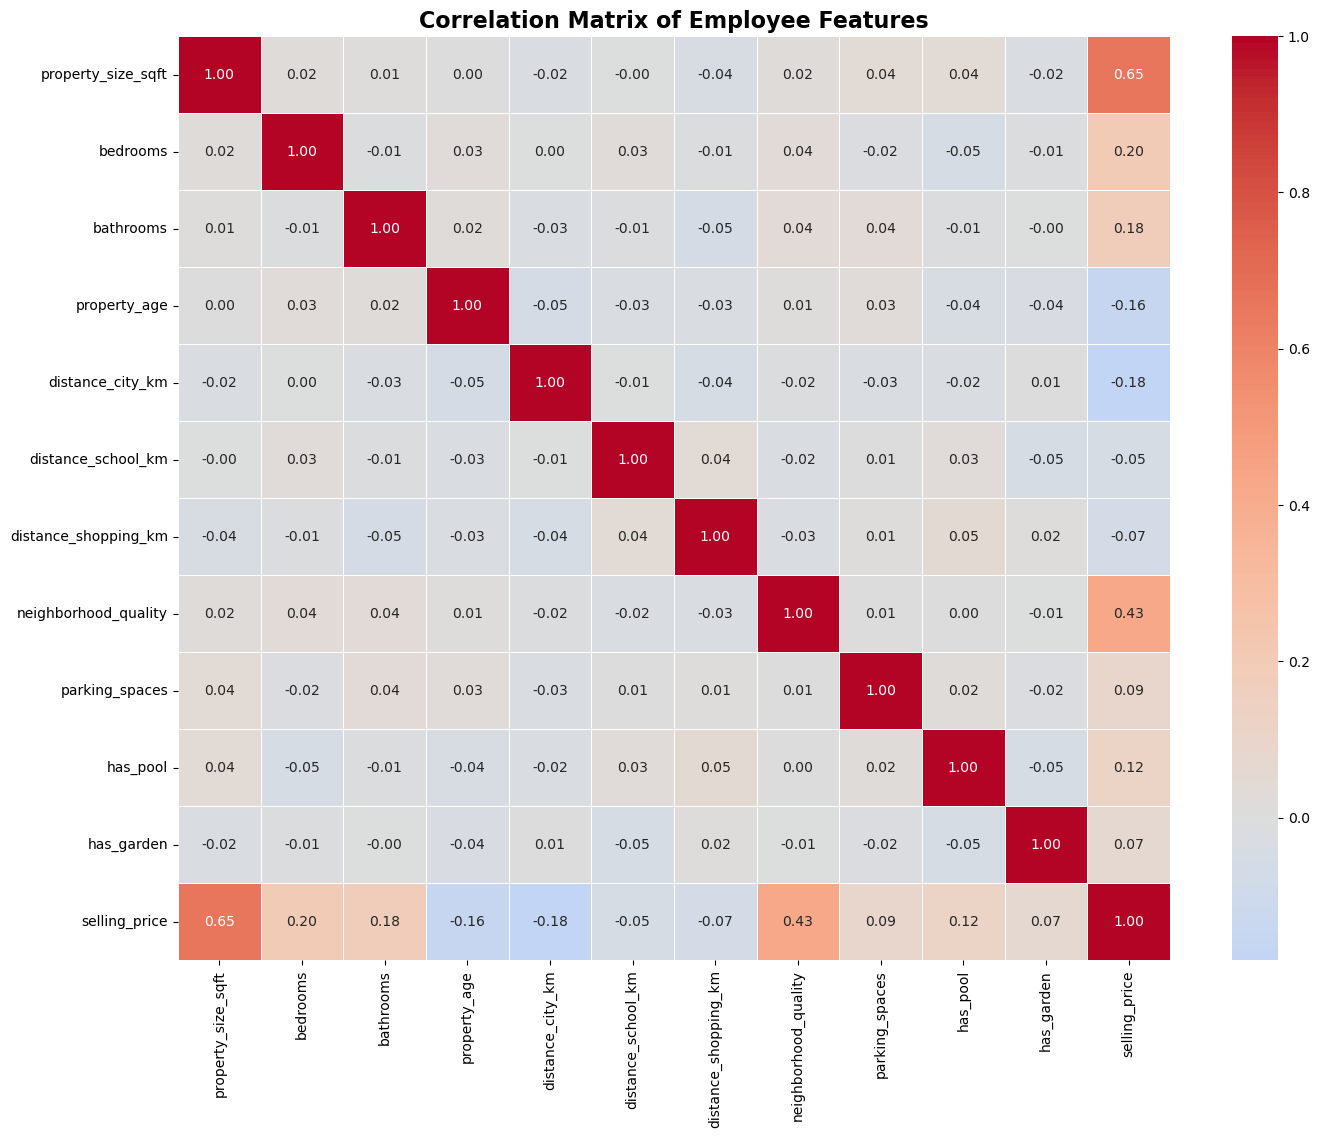

In [3]:
# Check the relationship between the explanatory variables 
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical features
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Calculate correlation matrix
correlation_matrix = numeric_df.corr(method="spearman")

# Set figure size
plt.figure(figsize=(16, 12))

# Create heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    center=0
)

# Add title
plt.title(
    "Correlation Matrix of Employee Features",
    fontsize=16,
    fontweight="bold"
)

# Display the plot
plt.show()

In [4]:
# Compute the Variance Inflation Factor (VIF)
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Select numerical explanatory variables

X_vif = df.select_dtypes(
    include=["int64", "float64"]
).drop(
    columns=["selling_price"]
)

# 2. Standardize the explanatory variables

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_vif)

# Convert back to DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_vif.columns,
    index=X_vif.index
)

# 3. Add intercept
X_constant = sm.add_constant(X_scaled)

# 4. Calculate VIF
vif = pd.DataFrame()

vif["Feature"] = X_constant.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_constant.values,
        i
    )
    for i in range(X_constant.shape[1])
]

# Remove the intercept from the final table
vif = vif[vif["Feature"] != "const"]

# 5. Sort VIF from highest to lowest

vif = vif.sort_values(
    by="VIF",
    ascending=False
).reset_index(drop=True)


# Display results
display(vif)


,Feature,VIF
0,has_pool,1.014585
1,distance_shopping_km,1.012527
2,distance_city_km,1.011214
3,property_age,1.010284
4,parking_spaces,1.009445
5,distance_school_km,1.008688
6,has_garden,1.007856
7,bedrooms,1.007783
8,property_size_sqft,1.007057
9,bathrooms,1.006482


In [11]:
# Separate explanatory variables (X) and target variable (y)

X = df.drop(columns=["property_id", "selling_price"])
y = df["selling_price"]

print("X dimensions:", X.shape)
print("y dimensions:", y.shape)

X dimensions: (1000, 13)
y dimensions: (1000,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (800, 13)
Testing set: (200, 13)


In [13]:
# Stardizing numeric explanatory variables for the train set
from sklearn.preprocessing import StandardScaler

# Numeric continuous variables to standardize
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

# Don't standardize binary variables
binary_features = ["has_pool", "has_garden"]

numeric_features = numeric_features.difference(binary_features)

scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

display(X_train.head())

,property_size_sqft,bedrooms,bathrooms,property_age,distance_city_km,distance_school_km,distance_shopping_km,neighborhood_quality,parking_spaces,property_condition,property_type,has_pool,has_garden
29,-0.333232,-0.261168,2.054889,1.619556,0.020083,-1.274752,-0.704706,-0.547213,0.117103,Excellent,Townhouse,0,1
535,0.017368,0.605780,0.209180,0.574049,3.818755,0.251027,-0.346889,0.157164,-0.998164,Very Good,Apartment,0,0
695,-0.351687,-1.128115,0.824416,-0.297207,-0.704141,-0.804599,1.124139,-0.195025,1.232370,Excellent,Apartment,1,1
557,-0.478859,0.605780,2.054889,-0.384333,-0.706478,1.204639,-0.719164,-0.195025,0.117103,Good,Apartment,0,0
836,1.571445,-0.261168,2.054889,-0.297207,-0.222883,-1.545311,0.661506,1.565920,1.232370,Good,Townhouse,0,1


In [15]:
# Now perform standardization on the test set

# Only include the numeric variables
numeric_features = X_test.select_dtypes(
    include=["int64", "float64"]
).columns

# Don't standardize binary variables
binary_features = ["has_pool", "has_garden"]
numeric_features = numeric_features.difference(binary_features)

X_test[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

# View the standardized explanatory variables
display(X_test.head())

,property_size_sqft,bedrooms,bathrooms,property_age,distance_city_km,distance_school_km,distance_shopping_km,neighborhood_quality,parking_spaces,property_condition,property_type,has_pool,has_garden
521,0.530155,0.605780,-1.636528,-0.122956,-0.549952,-0.600570,1.196425,-0.547213,-0.998164,Very Good,Townhouse,1,1
737,0.984371,2.339675,-1.021292,1.183928,-0.395762,0.898596,-0.617963,-1.251591,2.347636,Excellent,Apartment,1,1
740,-1.934937,-1.128115,-0.406056,0.835426,2.211445,0.428443,-0.798679,0.157164,0.117103,Very Good,Apartment,1,1
660,-0.624761,0.605780,0.824416,0.574049,-0.704141,-1.075158,0.318146,1.565920,0.117103,Very Good,Apartment,0,1
411,-1.194431,-1.128115,-0.406056,0.138421,-0.806935,-0.041709,-0.440861,-0.195025,0.117103,Fair,Apartment,0,1


In [17]:
from sklearn.preprocessing import OneHotEncoder
# Specify the categorical Variables
categorical_features = [
    "property_condition",
    "property_type"
]

# Apply one-hot coding for the TRAIN SET
encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

X_train_encoded = encoder.fit_transform(
    X_train[categorical_features]
)

# Converts the results from array to a nicely labeled dataframe
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(categorical_features),
    index=X_train.index
)

display(X_train_encoded.head())

,property_condition_Fair,property_condition_Good,property_condition_Poor,property_condition_Very Good,property_type_Detached House,property_type_Townhouse,property_type_Villa
29,0.0,0.0,0.0,0.0,0.0,1.0,0.0
535,0.0,0.0,0.0,1.0,0.0,0.0,0.0
695,0.0,0.0,0.0,0.0,0.0,0.0,0.0
557,0.0,1.0,0.0,0.0,0.0,0.0,0.0
836,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [18]:
# Include the one-hot coded variables to the dataframe
X_train_final = pd.concat(
    [
        X_train.drop(columns=categorical_features),
        X_train_encoded
    ],
    axis=1
)
display(X_train_final.head())

,property_size_sqft,bedrooms,bathrooms,property_age,distance_city_km,distance_school_km,distance_shopping_km,neighborhood_quality,parking_spaces,has_pool,has_garden,property_condition_Fair,property_condition_Good,property_condition_Poor,property_condition_Very Good,property_type_Detached House,property_type_Townhouse,property_type_Villa
29,-0.333232,-0.261168,2.054889,1.619556,0.020083,-1.274752,-0.704706,-0.547213,0.117103,0,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0
535,0.017368,0.605780,0.209180,0.574049,3.818755,0.251027,-0.346889,0.157164,-0.998164,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
695,-0.351687,-1.128115,0.824416,-0.297207,-0.704141,-0.804599,1.124139,-0.195025,1.232370,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
557,-0.478859,0.605780,2.054889,-0.384333,-0.706478,1.204639,-0.719164,-0.195025,0.117103,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
836,1.571445,-0.261168,2.054889,-0.297207,-0.222883,-1.545311,0.661506,1.565920,1.232370,0,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [19]:
from sklearn.preprocessing import OneHotEncoder
# Specify the categorical Variables
categorical_features = [
    "property_condition",
    "property_type"
]

# Apply one-hot coding for the TEST SET
encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

X_test_encoded = encoder.fit_transform(
    X_test[categorical_features]
)

# Converts the results from array to a nicely labeled dataframe
X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(categorical_features),
    index=X_test.index
)

display(X_test_encoded.head())

,property_condition_Fair,property_condition_Good,property_condition_Poor,property_condition_Very Good,property_type_Detached House,property_type_Townhouse,property_type_Villa
521,0.0,0.0,0.0,1.0,0.0,1.0,0.0
737,0.0,0.0,0.0,0.0,0.0,0.0,0.0
740,0.0,0.0,0.0,1.0,0.0,0.0,0.0
660,0.0,0.0,0.0,1.0,0.0,0.0,0.0
411,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
# Include the one-hot coded variables to the dataframe
X_test_final = pd.concat(
    [
        X_test.drop(columns=categorical_features),
        X_test_encoded
    ],
    axis=1
)
display(X_test_final.head())

,property_size_sqft,bedrooms,bathrooms,property_age,distance_city_km,distance_school_km,distance_shopping_km,neighborhood_quality,parking_spaces,has_pool,has_garden,property_condition_Fair,property_condition_Good,property_condition_Poor,property_condition_Very Good,property_type_Detached House,property_type_Townhouse,property_type_Villa
521,0.530155,0.605780,-1.636528,-0.122956,-0.549952,-0.600570,1.196425,-0.547213,-0.998164,1,1,0.0,0.0,0.0,1.0,0.0,1.0,0.0
737,0.984371,2.339675,-1.021292,1.183928,-0.395762,0.898596,-0.617963,-1.251591,2.347636,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
740,-1.934937,-1.128115,-0.406056,0.835426,2.211445,0.428443,-0.798679,0.157164,0.117103,1,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0
660,-0.624761,0.605780,0.824416,0.574049,-0.704141,-1.075158,0.318146,1.565920,0.117103,0,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0
411,-1.194431,-1.128115,-0.406056,0.138421,-0.806935,-0.041709,-0.440861,-0.195025,0.117103,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [55]:
# Lasso Regression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
import numpy as np
import warnings


# Ignore all warnings
warnings.filterwarnings("ignore")

# Assuming you have your features in X and target variable in y
# Define the Lasso regression model
lasso = Lasso()

# Define hyperparameters to tune
param_grid = {
    'alpha': [0.01, 0.1, 1.0, 10.0]  # Regularization strength
}

# Define setup for cross-validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Perform cross-validation grid search
lasso_grid_search = GridSearchCV(estimator=lasso, param_grid=param_grid, cv=cv, scoring='neg_root_mean_squared_error' )
lasso_grid_search.fit(X_train_final, y_train)

# Get the best hyperparameters
best_params = lasso_grid_search.best_params_
print("Best hyperparameters:", best_params)

# Get the best model
best_model = lasso_grid_search.best_estimator_
# CV RMSE of best model
cv_rmse = -lasso_grid_search.best_score_  # negate because sklearn uses "maximize" convention
print("Mean 5-fold CV RMSE:", np.round(cv_rmse,2))

# Evaluate the best model on the train set using RMSE
y_train_pred = best_model.predict(X_train_final)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))  # RMSE on train set
print("Root Mean Squared Error on train set:", np.round(rmse_train,2))

# Calculate train R²
train_r2 = r2_score(y_train, y_train_pred)
print("Train R²:", train_r2)

Best hyperparameters: {'alpha': 10.0}
Mean 5-fold CV RMSE: 49796.98
Root Mean Squared Error on train set: 48735.2
Train R²: 0.9163382394590306


In [36]:
# Evaluate the best Lasso model on the test set using RMSE
y_test_pred = best_model.predict(X_test_final)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))  # RMSE on test set
print("Root Mean Squared Error on test set:", np.round(rmse_test,2))

# Calculate test R²
test_r2 = r2_score(y_test, y_test_pred)
print("Test R²:", test_r2)

Root Mean Squared Error on test set: 52284.58
Test R²: 0.9075636730829574


In [56]:
# Ridge Regression
# Training a machine learning model for a regression problem using the x_train_final dataset and the
# outcome variable y_train.
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Assuming you have your features in X and target variable in y
# Define Ridge regression model
ridge = Ridge()

# Define hyperparameters to tune
param_grid = {
    'alpha': [0.01, 0.1, 1.0, 10.0]  # Regularization strength
}

# Define setup for cross-validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Perform cross-validation grid search
ridge_grid_search = GridSearchCV(estimator=ridge, param_grid=param_grid, cv=cv, scoring='neg_root_mean_squared_error' ) # cv=5 for 5-fold cross-validation
ridge_grid_search.fit(X_train_final, y_train)

# Get the best hyperparameters
best_params = ridge_grid_search.best_params_
print("Best hyperparameters:", best_params)

# Get the best model
best_model = ridge_grid_search.best_estimator_
# CV RMSE of best model
cv_rmse = -ridge_grid_search.best_score_  # negate because sklearn uses "maximize" convention
print("Mean 5-fold CV RMSE:", np.round(cv_rmse,2))

# Evaluate the best model on the train set using RMSE
y_train_pred = best_model.predict(X_train_final)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))  # RMSE on train set
print("Root Mean Squared Error on train set:", np.round(rmse_train,2))

# Calculate train R²
train_r2 = r2_score(y_train, y_train_pred)
print("Train R²:", train_r2)

Best hyperparameters: {'alpha': 0.1}
Mean 5-fold CV RMSE: 49795.44
Root Mean Squared Error on train set: 48735.22
Train R²: 0.9163381719206153


In [57]:
# Evaluate the best Ridge model on the test set using RMSE
y_test_pred = best_model.predict(X_test_final)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))  # RMSE on test set
print("Root Mean Squared Error on test set:", np.round(rmse_test,2))

# Calculate test R²
test_r2 = r2_score(y_test, y_test_pred)
print("Test R²:", test_r2)

Root Mean Squared Error on test set: 52282.35
Test R²: 0.9075715694059338


In [59]:
# Elastic Net Regression
# Import necessary libraries
import numpy as np
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_regression

# Define the hyperparameter grid for Elastic Net
parametersGrid = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
    "l1_ratio": np.arange(0.1, 1.0, 0.1)
}

# Define setup for cross-validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Initialize the Elastic Net model
eNet = ElasticNet()

# Perform grid search to find the best hyperparameters
elastic_grid_search  = GridSearchCV(eNet, parametersGrid, scoring='neg_root_mean_squared_error', cv=cv)
elastic_grid_search.fit(X_train_final, y_train)

# Get the best hyperparameters
best_params = elastic_grid_search.best_params_
print("Best hyperparameters:", best_params)

# Get the best model
best_model = elastic_grid_search.best_estimator_
# CV RMSE of best model
cv_rmse = -elastic_grid_search.best_score_  # negate because sklearn uses "maximize" convention
print("Mean 5-fold CV RMSE:", np.round(cv_rmse,2))

# Evaluate the best model on the train set using RMSE
y_train_pred = best_model.predict(X_train_final)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))  # RMSE on train set
print("Root Mean Squared Error on train set:", np.round(rmse_train,2))

Best hyperparameters: {'alpha': 0.001, 'l1_ratio': np.float64(0.30000000000000004)}
Mean 5-fold CV RMSE: 49791.61
Root Mean Squared Error on train set: 48741.47


In [54]:
# Evaluate the best model on the test set using RMSE
y_test_pred = best_model.predict(X_test_final)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))  # RMSE on test set
print("Root Mean Squared Error on test set:", np.round(rmse_test,2))

# Calculate test R²
test_r2 = r2_score(y_test, y_test_pred)
print("Test R²:", test_r2)

Root Mean Squared Error on test set: 52202.34
Test R²: 0.9078542433702902


In [63]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Lasso": lasso_grid_search,
    "Ridge": ridge_grid_search,
    "Elastic Net": elastic_grid_search
}

results = []

for name, grid in models.items():

    # Best model
    best_model = grid.best_estimator_

    # Predictions
    y_train_pred = best_model.predict(X_train_final)
    y_test_pred = best_model.predict(X_test_final)

    # CV RMSE
    cv_rmse = -grid.best_score_

    # Train metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)

    # Test metrics
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)

    results.append({
        "Model": name,
        "CV RMSE": cv_rmse,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R²": train_r2,
        "Test R²": test_r2
    })

results_df = pd.DataFrame(results)

# Round the values
results_df.iloc[:, 1:] = results_df.iloc[:, 1:].round(5)

display(results_df)

,Model,CV RMSE,Train RMSE,Test RMSE,Train R²,Test R²
0,Lasso,49796.98005,48735.20264,52284.58131,0.91634,0.90756
1,Ridge,49795.44041,48735.22231,52282.34807,0.91634,0.90757
2,Elastic Net,49791.60546,48741.46755,52202.33927,0.91632,0.90785
